## Preparation

In [ ]:
#!pip install sentence-transformers
#!pip install pyannote.audio
#from sentence_transformers import SentenceTransformer
#from pyannote.audio import Pipeline
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import DataLoader, Dataset

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import json
import math
import subprocess
import inspect
import re

In [ ]:
# Hyperparameters
SAMPLE_RATE = 16000
STRIDE_SIZE = 3
BATCH_SIZE = 1
LR = 1e-4
EPOCHS = 50
THRESHOLD = 0.5
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_SPEAKERS = 5
N_COMPONENTS = 3

bundle = torchaudio.pipelines.WAV2VEC2_BASE
WAV2VEC = bundle.get_model().to(DEVICE)

token = 'your-api-token'
MODEL = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device=DEVICE, token=token)

#PIPELINE = Pipeline.from_pretrained("pyannote/speaker-diarization-community-1", token=token).to(torch.device(DEVICE))

api = 'gemini-token'

In [ ]:
env = 'COLAB'

if env == 'COLAB':
    from google.colab import drive
    drive.mount('/content/drive')
    path = Path('/content/drive/MyDrive/Individual_Project')
else:
    path = Path('./')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Pre-processing

In [ ]:
from collections import defaultdict

def reconstruct(word_segments):
    segments = []
    current_segment = None
    current_line = ''
    current_start = None
    speakers = defaultdict(float)
    for word_segment in word_segments:
        start, end = word_segment['start'], word_segment['end']
        current_start = current_start or start
        if 'speaker' in word_segment:
            speakers[word_segment['speaker']] += end - start
        word = word_segment['word']
        current_line += word + ' '
        if word[-1] in ('.', '?', '!'):
            if speakers:
                speaker = max(speakers.keys(), key=lambda s: speakers[s])
                if not current_segment or current_segment['speaker'] != speaker or \
                   current_segment['end'] - current_segment['start'] > 30 or \
                   current_start - current_segment['end'] > 10:
                    segments.append(current_segment)
                    current_segment = {
                        'start': current_start,
                        'end': end,
                        'speaker': speaker,
                        'text': current_line,
                    }
                else:
                    current_segment['end'] = end
                    current_segment['text'] += current_line
            current_line, current_start = '', None
            speakers = defaultdict(float)
    if current_segment:
        segments.append(current_segment)

    segments = segments[1:]
    segments_ = []
    current_segment, speaker = None, None
    skip = False
    for i, segment in enumerate(segments):
        if skip:
            skip = False
            continue
        start, end = segment['start'], segment['end']
        if not current_segment:
            current_segment, speaker = segment.copy(), segment['speaker']
        elif current_segment['speaker'] == speaker and start - current_segment['end'] <= 10 and segment['speaker'] != speaker and end - start <= 10 and \
            i != len(segments) - 1 and segments[i + 1]['start'] - end <= 10 and segments[i + 1]['speaker'] == speaker:
            current_segment['text'] += segment['text'] + segments[i + 1]['text']
            current_segment['end'] = segments[i + 1]['end']
            skip = True
        else:
            if current_segment['end'] - current_segment['start'] >= 1:
                segments_.append(current_segment)
            if end - start >= 1:
                current_segment, speaker = segment.copy(), segment['speaker']
            else:
                current_segment, speaker = None, None
    if current_segment:
        segments_.append(current_segment)

    return segments_

'''
with open(path / 'data' / 'labels.json') as f:
    labels = json.load(f)
for label in labels:
    audio_path = path / 'data' / label['audio_path']
    with open(path / 'data' / 'transcript' / f'{audio_path.parent.name}_{audio_path.stem}_aligned.json') as f:
        transcript = json.load(f)
    segments = reconstruct(transcript['word_segments'])
    with open(path / 'data' / 'transcript' / f'{audio_path.parent.name}_{audio_path.stem}_reconstructed2.json', 'w') as f:
        json.dump(segments, f, indent=2)
    print(f'Completed {audio_path}')
'''

"\nwith open(path / 'data' / 'labels.json') as f:\n    labels = json.load(f)\nfor label in labels:\n    audio_path = path / 'data' / label['audio_path']\n    with open(path / 'data' / 'transcript' / f'{audio_path.parent.name}_{audio_path.stem}_aligned.json') as f:\n        transcript = json.load(f)\n    segments = reconstruct(transcript['word_segments'])\n    with open(path / 'data' / 'transcript' / f'{audio_path.parent.name}_{audio_path.stem}_reconstructed2.json', 'w') as f:\n        json.dump(segments, f, indent=2)\n    print(f'Completed {audio_path}')\n"

In [ ]:
#!pip install whisperx
import whisperx
from whisperx.diarize import DiarizationPipeline
import time
import threading
from pynvml import *
nvmlInit()
handle = nvmlDeviceGetHandleByIndex(0)
running = True
samples = []

def monitor():
    global samples
    while running:
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        samples.append((util.gpu, mem.used / 1024**3))
        time.sleep(1)

def benchmark(f):
    global running, profiles
    running = True
    samples.clear()
    t = threading.Thread(target=monitor)
    start = time.perf_counter()
    t.start()
    result = f()
    time_ = time.perf_counter() - start
    running = False
    t.join()
    gpu_util, gpu_mem = np.array(samples).mean(axis=0)
    profiles[-1].extend([time_, float(gpu_util), float(gpu_mem)])
    print(time_, gpu_util, gpu_mem)
    torch.cuda.empty_cache()
    return result

'''
with open(path / 'profiles.json') as f:
    profiles = json.load(f)
print(len(profiles))

model = whisperx.load_model('large-v3', DEVICE, compute_type='float16', language='en')
model_a, metadata = whisperx.load_align_model(language_code='en', device=DEVICE)
diarize_model = DiarizationPipeline(token="your-api-token", device=DEVICE)
'''
profiles = []

data_path = Path(path / 'data')
with open(data_path / 'labels.json') as f:
    labels = json.load(f)
transcript_dir = data_path / 'transcript'
transcript_dir.mkdir(exist_ok=True)
labels.sort(key=lambda x: x['audio_path'])

audio_paths = ['2024-06-03.wav', '2024-10-07.wav', '2024-12-02.wav', '2026-01-15.wav', '2026-01-16.wav',
               '50010/2025-05-27.wav', '50010/2025-05-28.wav', '60013/2026-02-02.wav',
               '50009/2025-03-07.wav', '60017/2026-02-13.wav']
for p in audio_paths:
    assert Path(data_path / p).exists()

for i, p in enumerate(audio_paths):
    profiles.append([])
    audio_path = data_path / p
    print(p)
    audio = whisperx.load_audio(str(audio_path))
    transcript = benchmark(lambda: model.transcribe(audio, batch_size=16, language='en'))
    segments = transcript['segments']
    segments = [
        segment for segment in segments
        if len(re.sub(r"yeah\.|thank you\.|maybe\.", '', segment['text'].strip().lower()).split()) >= 5
    ]

    transcript = benchmark(lambda: whisperx.align(segments, model_a, metadata, audio, DEVICE, return_char_alignments=False))
    diarize_segments = benchmark(lambda: diarize_model(audio))
    result = whisperx.assign_word_speakers(diarize_segments, transcript)
    text_segments = reconstruct(result['word_segments'])
    _ = benchmark(lambda: MODEL.encode([segment['text'] for segment in text_segments]))

    audio, _ = torchaudio.load(audio_path)
    audio = audio.to(DEVICE)
    duration = int(len(audio[0]) / SAMPLE_RATE)

    def wav2vec_segments(audio, transcript):
        for segment in transcript:
            s, e = int(segment['start'] * SAMPLE_RATE), int(segment['end'] * SAMPLE_RATE)
            wav2vec_embedding(audio[0, s:e])
    benchmark(lambda: wav2vec_segments(audio, text_segments))
    profiles[-1].append(duration)
    print(profiles[-1])
    with open(path / 'profiles2.json', 'w') as f:
        json.dump(profiles, f, indent=2)

    #
    #with open(transcript_dir / f'{audio_path.parent.name}_{audio_path.stem}_aligned.json', 'w') as f:
    #    json.dump(result, f, indent=2)
    #print(f'Completed {audio_path}')

2024-06-03.wav
171.65988954000022 96.99411764705883 9.233799833409927
74.31042146300024 30.30666666666667 5.8564851888020835


/usr/local/lib/python3.12/dist-packages/pyannote/audio/models/blocks/pooling.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  std = sequences.std(dim=-1, correction=1)


202.64820642400036 95.41089108910892 7.436561508934097
1.3201793549997092 75.0 5.18768310546875


/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

41.8650759090001 97.61904761904762 8.937311081659226
[171.65988954000022, 96.99411764705883, 9.233799833409927, 74.31042146300024, 30.30666666666667, 5.8564851888020835, 202.64820642400036, 95.41089108910892, 7.436561508934097, 1.3201793549997092, 75.0, 5.18768310546875, 41.8650759090001, 97.61904761904762, 8.937311081659226, 4182]
2024-10-07.wav
231.49791552499983 98.05194805194805 8.74237906055533
102.57406582099975 37.61165048543689 6.511465720760012
300.15036266100014 95.5551839464883 7.4433595791309575
1.7009644220001974 77.0 5.21405029296875


...

55.5465716030003 98.35714285714286 10.292035784040179
[245.4765085480003, 98.26938775510204, 9.017147391183036, 104.63147991799997, 35.50476190476191, 5.6106183733258925, 350.6620155600003, 94.86571428571429, 7.443079310825893, 2.1083431710003424, 71.0, 5.503438313802083, 55.5465716030003, 98.35714285714286, 10.292035784040179, 7198]
50009/2025-03-07.wav
93.71034779000001 96.88297872340425 8.641701556266622
46.71647708100045 39.0 5.754172467170878
173.52726681700005 95.22413793103448 7.435247311646911
0.8470615930000349 0.0 4.91619873046875


/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

29.477239746999658 96.66666666666667 9.862943522135417
[93.71034779000001, 96.88297872340425, 8.641701556266622, 46.71647708100045, 39.0, 5.754172467170878, 173.52726681700005, 95.22413793103448, 7.435247311646911, 0.8470615930000349, 0.0, 4.91619873046875, 29.477239746999658, 96.66666666666667, 9.862943522135417, 3598]
60017/2026-02-13.wav
216.65121829100008 96.57142857142857 8.864769438994095
101.06185195599937 34.28712871287129 6.950291397547958
337.8117255139996 95.35014836795253 7.445872320973201
1.6760482789995876 78.5 5.16424560546875


/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

58.512552485000015 98.49152542372882 10.255744546146715
[216.65121829100008, 96.57142857142857, 8.864769438994095, 101.06185195599937, 34.28712871287129, 6.950291397547958, 337.8117255139996, 95.35014836795253, 7.445872320973201, 1.6760482789995876, 78.5, 5.16424560546875, 58.512552485000015, 98.49152542372882, 10.255744546146715, 6964]


In [ ]:
profiles = np.array(profiles)
profiles.shape

(10, 16)

In [ ]:
order = np.argsort(profiles[:, -1])
profiles_ = np.hstack((profiles[order, -1:], profiles[order, :-1], np.array(ps[1:11])))

In [ ]:
import json
import numpy as np

with open(path / 'profiles2.json') as f:
    profiles_ = json.load(f)
profiles_ = np.array(profiles_)
profiles_[-1:].shape

array([[1.71659890e+02, 9.69941176e+01, 9.23379983e+00, 7.43104215e+01,
        3.03066667e+01, 5.85648519e+00, 2.02648206e+02, 9.54108911e+01,
        7.43656151e+00, 1.32017935e+00, 7.50000000e+01, 5.18768311e+00,
        4.18650759e+01, 9.76190476e+01, 8.93731108e+00, 4.18200000e+03],
       [2.31497916e+02, 9.80519481e+01, 8.74237906e+00, 1.02574066e+02,
        3.76116505e+01, 6.51146572e+00, 3.00150363e+02, 9.55551839e+01,
        7.44335958e+00, 1.70096442e+00, 7.70000000e+01, 5.21405029e+00,
        5.69539170e+01, 9.82456140e+01, 8.48651123e+00, 6.16700000e+03],
       [2.42846515e+02, 9.78065844e+01, 8.90456839e+00, 1.06402682e+02,
        3.69719626e+01, 6.16645428e+00, 3.29925862e+02, 9.56869301e+01,
        7.44417175e+00, 1.94305228e+00, 7.85000000e+01, 5.15252686e+00,
        6.10631998e+01, 9.83934426e+01, 1.20613383e+01, 6.82100000e+03],
       [1.87443468e+02, 9.77819149e+01, 8.94306459e+00, 7.82175748e+01,
        3.63164557e+01, 5.60775332e+00, 2.63602086e+02, 9.439

In [ ]:
string = '''3215.00 & 0.92 & 29.00 & 4.92 & 31.37 & 97.12 & 8.47 & 1.00 & 0.00 & 5.63 \\
3598.00 & 0.85 & 0.00 & 4.92 & 29.48 & 96.67 & 9.86 & 1.03 & 0.00 & 5.63 \\
4182.00 & 1.32 & 75.00 & 5.19 & 41.87 & 97.62 & 8.94 & 1.03 & 1.00 & 5.63 \\
4472.00 & 1.27 & 75.50 & 5.17 & 37.65 & 97.53 & 9.03 & 1.03 & 1.00 & 5.63 \\
5382.00 & 1.73 & 59.00 & 5.36 & 39.77 & 97.50 & 10.70 & 1.04 & 0.00 & 5.63 \\
6167.00 & 1.70 & 77.00 & 5.21 & 56.95 & 98.25 & 8.49 & 1.03 & 0.00 & 5.63 \\
6398.00 & 1.85 & 78.50 & 5.16 & 61.75 & 98.40 & 10.30 & 1.04 & 1.00 & 5.61 \\
6821.00 & 1.94 & 78.50 & 5.15 & 61.06 & 98.39 & 12.06 & 1.04 & 1.00 & 5.62 \\
6964.00 & 1.68 & 78.50 & 5.16 & 58.51 & 98.49 & 10.26 & 1.04 & 2.00 & 5.63 \\
7198.00 & 2.11 & 71.00 & 5.50 & 55.55 & 98.36 & 10.29 & 1.04 & 0.00 & 5.63 \\'''
ps = [[float(d) for d in s.split(' & ')[-3:]] for s in string.split(' \\')[:-1]]
ps

[[1.0, 0.0, 5.63],
 [1.03, 0.0, 5.63],
 [1.03, 1.0, 5.63],
 [1.03, 1.0, 5.63],
 [1.04, 0.0, 5.63],
 [1.03, 0.0, 5.63],
 [1.04, 1.0, 5.61],
 [1.04, 1.0, 5.62],
 [1.04, 2.0, 5.63],
 [1.04, 0.0, 5.63]]

In [ ]:
profiles_ = np.hstack((profiles_[:, -1:], profiles_[:, :-1], np.array(ps)))
profiles_

array([[4.18200000e+03, 1.71659890e+02, 9.69941176e+01, 9.23379983e+00,
        7.43104215e+01, 3.03066667e+01, 5.85648519e+00, 2.02648206e+02,
        9.54108911e+01, 7.43656151e+00, 1.32017935e+00, 7.50000000e+01,
        5.18768311e+00, 4.18650759e+01, 9.76190476e+01, 8.93731108e+00,
        1.00000000e+00, 0.00000000e+00, 5.63000000e+00],
       [6.16700000e+03, 2.31497916e+02, 9.80519481e+01, 8.74237906e+00,
        1.02574066e+02, 3.76116505e+01, 6.51146572e+00, 3.00150363e+02,
        9.55551839e+01, 7.44335958e+00, 1.70096442e+00, 7.70000000e+01,
        5.21405029e+00, 5.69539170e+01, 9.82456140e+01, 8.48651123e+00,
        1.03000000e+00, 0.00000000e+00, 5.63000000e+00],
       [6.82100000e+03, 2.42846515e+02, 9.78065844e+01, 8.90456839e+00,
        1.06402682e+02, 3.69719626e+01, 6.16645428e+00, 3.29925862e+02,
        9.56869301e+01, 7.44417175e+00, 1.94305228e+00, 7.85000000e+01,
        5.15252686e+00, 6.10631998e+01, 9.83934426e+01, 1.20613383e+01,
        1.03000000e+00

0.9587006995078147


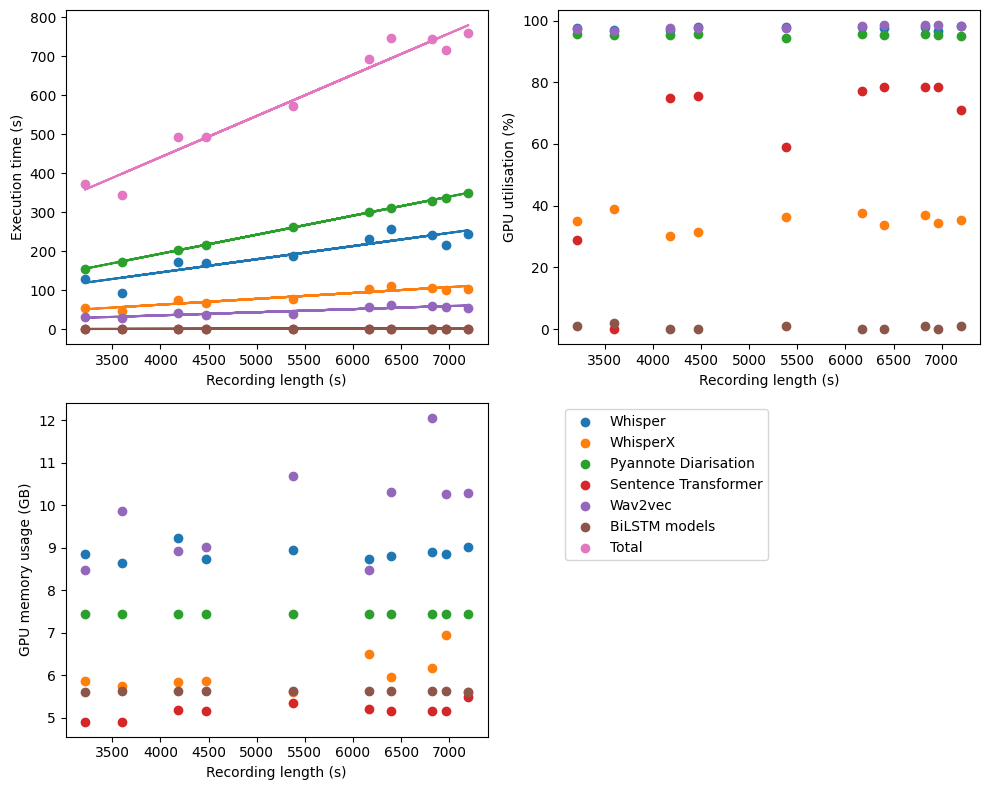

In [ ]:
titles = ['Execution time', 'GPU utilisation', 'GPU memory usage']
ylabels = ['Execution time (s)', 'GPU utilisation (%)', 'GPU memory usage (GB)']
labels = ['Whisper', 'WhisperX', 'Pyannote Diarisation', 'Sentence Transformer', 'Wav2vec', 'BiLSTM models', 'Total']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
cmap = plt.get_cmap('tab10')
for i, (title, ax) in enumerate(zip(titles, axes)):
    for j, execution_time in enumerate(profiles_[:, i+1::3].T):
        if i == 0:
            m, b = np.polyfit(profiles_[:, 0], execution_time, 1)
            ax.plot(profiles_[:, 0], m * profiles_[:, 0] + b, color=cmap(j))
        ax.scatter(profiles_[:, 0], execution_time, label=labels[j], color=cmap(j))
    if i == 0:
        execution_time = profiles_[:, 1::3].sum(axis=1)
        ax.scatter(profiles_[:, 0], execution_time, label='Total', color=cmap(6))
        m, b = np.polyfit(profiles_[:, 0], execution_time, 1)
        ax.plot(profiles_[:, 0], m * profiles_[:, 0] + b, color=cmap(6))
        print(1 - np.sum((execution_time - m * profiles_[:, 0] - b) ** 2) / np.sum((execution_time - execution_time.mean()) ** 2))
    ax.set_xlabel('Recording length (s)')
    ax.set_ylabel(ylabels[i])
    #ax.set_title(title)

axes[3].axis('off')

handles, labels_ = axes[0].get_legend_handles_labels()
axes[3].legend(handles, labels_, loc='upper left')
plt.tight_layout()
plt.savefig(path / 'performance.png', dpi=300)

In [ ]:
for data in profiles_:
    print(' & '.join(f'{float(d):.2f}' for d in data[[0, 10, 11, 12, 13, 14, 15, 16, 17, 18]]) + ' \\\\')

3215.00 & 0.92 & 29.00 & 4.92 & 31.37 & 97.12 & 8.47 & 1.00 & 0.00 & 5.63 \\
3598.00 & 0.85 & 0.00 & 4.92 & 29.48 & 96.67 & 9.86 & 1.03 & 0.00 & 5.63 \\
4182.00 & 1.32 & 75.00 & 5.19 & 41.87 & 97.62 & 8.94 & 1.03 & 1.00 & 5.63 \\
4472.00 & 1.27 & 75.50 & 5.17 & 37.65 & 97.53 & 9.03 & 1.03 & 1.00 & 5.63 \\
5382.00 & 1.73 & 59.00 & 5.36 & 39.77 & 97.50 & 10.70 & 1.04 & 0.00 & 5.63 \\
6167.00 & 1.70 & 77.00 & 5.21 & 56.95 & 98.25 & 8.49 & 1.03 & 0.00 & 5.63 \\
6398.00 & 1.85 & 78.50 & 5.16 & 61.75 & 98.40 & 10.30 & 1.04 & 1.00 & 5.61 \\
6821.00 & 1.94 & 78.50 & 5.15 & 61.06 & 98.39 & 12.06 & 1.04 & 1.00 & 5.62 \\
6964.00 & 1.68 & 78.50 & 5.16 & 58.51 & 98.49 & 10.26 & 1.04 & 2.00 & 5.63 \\
7198.00 & 2.11 & 71.00 & 5.50 & 55.55 & 98.36 & 10.29 & 1.04 & 0.00 & 5.63 \\


## Utils

In [ ]:
def compute_segment_labels(gt_segments, transcript_segments, overlap_threshold=0.2):
    labels = []
    for seg in transcript_segments:
        s0 = seg["start"]
        s1 = seg["end"]
        seg_len = max(s1 - s0, 1e-6)
        max_overlap_ratio = 0.0

        for gt in gt_segments:
            g0 = gt["start"]
            g1 = gt["end"]
            inter = max(0.0, min(s1, g1) - max(s0, g0))

            overlap_ratio = inter / seg_len
            max_overlap_ratio = max(max_overlap_ratio, overlap_ratio)

        label = int(max_overlap_ratio >= overlap_threshold)
        labels.append(label)

    return torch.tensor(labels, device=DEVICE)


def compute_ipc(gt_segments, pred_segments):
    if len(pred_segments) == 0:
        return 0
    if len(gt_segments) == 0:
        return len(pred_segments)

    gt_start = gt_segments[:, 0].unsqueeze(0)
    gt_end = gt_segments[:, 1].unsqueeze(0)

    pred_start = pred_segments[:, 0].unsqueeze(1)
    pred_end = pred_segments[:, 1].unsqueeze(1)

    inter_start = torch.maximum(pred_start, gt_start)
    inter_end = torch.minimum(pred_end, gt_end)

    intersection = (inter_end - inter_start).clamp(min=0)
    has_overlap = (intersection > 0).any(dim=1)
    return (~has_overlap).sum().item()


def compute_iou(gt_segments, pred_segments):
    if len(gt_segments) == 0 or len(pred_segments) == 0:
        return np.array([0.0, 0.0])

    gt_start = gt_segments[:, 0:1]
    gt_end = gt_segments[:, 1:2]
    pred_start = pred_segments[:, 0].unsqueeze(0)
    pred_end = pred_segments[:, 1].unsqueeze(0)

    inter_start = torch.maximum(gt_start, pred_start)
    inter_end = torch.minimum(gt_end, pred_end)
    intersection = (inter_end - inter_start).clamp(min=0)
    intersection = intersection.sum()

    gt_total = (gt_segments[:, 1] - gt_segments[:, 0]).sum()
    pred_total = (pred_segments[:, 1] - pred_segments[:, 0]).sum()
    union = gt_total + pred_total - intersection

    if union <= 0:
        return 1.0
    return np.array([intersection.item(), union.item()])


def merge_gap(segments, gap=0.0):
    if len(segments) == 0:
        return segments

    merged = []
    cur_start = segments[0, 0]
    cur_end = segments[0, 1]

    for i in range(1, len(segments)):
        start = segments[i, 0]
        end = segments[i, 1]

        if start <= cur_end + gap:
            cur_end = torch.maximum(cur_end, end)
        else:
            merged.append(torch.stack([cur_start, cur_end]))
            cur_start = start
            cur_end = end

    merged.append(torch.stack([cur_start, cur_end]))
    return torch.stack(merged)


def compute_recall(gt_segments, pred_segments):
    if len(gt_segments) == 0 or len(pred_segments) == 0:
        return np.array([0.0, 0.0])

    gt_start = gt_segments[:, 0:1]
    gt_end = gt_segments[:, 1:2]
    pred_start = pred_segments[:, 0].unsqueeze(0)
    pred_end = pred_segments[:, 1].unsqueeze(0)

    inter_start = torch.maximum(gt_start, pred_start)
    inter_end = torch.minimum(gt_end, pred_end)
    intersection = (inter_end - inter_start).clamp(min=0)
    intersection = intersection.sum()

    gt_total = (gt_segments[:, 1] - gt_segments[:, 0]).sum()
    if gt_total <= 0:
        return np.array([0.0, 0.0])
    return np.array([intersection.item(), gt_total.item()])


def compute_precision(gt_segments, pred_segments):
    if len(gt_segments) == 0 or len(pred_segments) == 0:
        return np.array([0.0, 0.0])

    gt_start = gt_segments[:, 0:1]
    gt_end = gt_segments[:, 1:2]
    pred_start = pred_segments[:, 0].unsqueeze(0)
    pred_end = pred_segments[:, 1].unsqueeze(0)

    inter_start = torch.maximum(gt_start, pred_start)
    inter_end = torch.minimum(gt_end, pred_end)
    intersection = (inter_end - inter_start).clamp(min=0)
    intersection = intersection.sum()

    pred_total = (pred_segments[:, 1] - pred_segments[:, 0]).sum()
    if pred_total <= 0:
        return np.array([0.0, 0.0])
    return np.array([intersection.item(), pred_total.item()])


def extend_relevant_segments(predicted_mask, transcript_segments, transcript_texts, min_words=5, min_word_density=0.5, max_gap=40.0):
    def is_information_heavy(i):
        text = transcript_texts[i][1][0].strip().lower()
        if not text:
            return False

        words = re.sub(r"yeah\.|thank you\.", '', text).split()
        return len(words) >= max(min_words, min_word_density * durations[i])

    N = transcript_segments.size(0)
    extended = predicted_mask.clone()
    durations = transcript_segments[:, 1] - transcript_segments[:, 0]
    info_heavy = torch.tensor([is_information_heavy(i) for i in range(N)], device=DEVICE)

    i = 0
    while i < N:
        if not predicted_mask[i]:
            i += 1
            continue

        left = right = i
        while right + 1 < N and predicted_mask[right + 1]:
            right += 1

        speaker_durations = defaultdict(float)
        for i in range(left, min(right, left + 5)):
            speaker_id, _ = transcript_texts[i]
            speaker_durations[speaker_id] += durations[i]

        speaker_id, _ = max(speaker_durations.items(), default=(-2, None), key=lambda item: item[1])
        temp = left
        while temp > 0:
            prev_speaker, _ = transcript_texts[temp - 1]
            if transcript_segments[left, 0] - transcript_segments[temp - 1, 1] > max_gap:
                break
            elif prev_speaker == speaker_id and info_heavy[temp - 1]:
                left = temp
            temp -= 1

        speaker_durations = defaultdict(float)
        for i in range(max(left, right - 5), right):
            speaker_id, _ = transcript_texts[i]
            speaker_durations[speaker_id] += durations[i]

        speaker_id, _ = max(speaker_durations.items(), default=(-2, None), key=lambda item: item[1])
        temp = right
        while temp < N - 1:
            next_speaker, _ = transcript_texts[temp + 1]
            if transcript_segments[temp + 1, 0] - transcript_segments[right, 1] > max_gap:
                break
            elif next_speaker == speaker_id and info_heavy[temp + 1]:
                right = temp
            temp += 1

        extended[left:right + 1] = True
        i = right + 1
    return extended


@torch.no_grad()
def wav2vec_embedding(
    audio,
    window_sec=10,
    stride_sec=5,
    batch_size=32
):
    WAV2VEC.eval()

    # mono
    if audio.dim() == 2:
        audio = audio.mean(dim=0)
    audio = audio.to(DEVICE).float()

    window = int(window_sec * SAMPLE_RATE)
    stride = int(stride_sec * SAMPLE_RATE)
    chunks = []

    # 1) slice ALL chunks first (no model call yet)
    for start in range(0, len(audio) - window + 1, stride):
        end = start + window
        chunk = audio[start:end]
        if chunks and len(chunk) < SAMPLE_RATE:  # skip too short
            continue
        chunks.append(chunk)

    if len(chunks) == 0:
        return torch.zeros(1, 768, device=DEVICE)

    embeddings = []
    # 2) batch inference
    for i in range(0, len(chunks), batch_size):
        batch = torch.stack(chunks[i:i+batch_size])
        outputs, _ = WAV2VEC(batch)
        hidden = outputs  # [B, T, D]
        emb = hidden.mean(dim=1)  # [B, D]
        embeddings.append(emb)
    return torch.cat(embeddings, dim=0).mean(dim=0, keepdim=True)

from collections import defaultdict

def compute_diarization_features(transcript_segments, diarization, alpha=0.2, kernel_size=21):
    n_segments = len(transcript_segments)
    speech_densities = torch.zeros((n_segments, N_SPEAKERS), device=DEVICE)
    speaker_counts = torch.zeros(n_segments, device=DEVICE)
    speaker_fractions = torch.zeros(N_SPEAKERS, device=DEVICE)
    speech_entropy = torch.zeros(n_segments, device=DEVICE)
    word_densities = torch.zeros(n_segments, device=DEVICE)
    durations = defaultdict(float)

    for seg in diarization:
        speaker = seg["speaker"]
        durations[speaker] += seg["end"] - seg["start"]
    if len(durations) == 0:
        return torch.cat([speech_densities, speaker_counts], dim=1)

    speaker_durations = torch.tensor(list(durations.values()), device=DEVICE)
    speakers = list(durations.keys())
    order = torch.argsort(speaker_durations, descending=True)[:N_SPEAKERS]
    top_speakers = [speakers[i] for i in order.tolist()]

    for seg_idx, tseg in enumerate(transcript_segments):
        t0 = tseg["start"]
        t1 = tseg["end"]
        seg_len = max(t1 - t0, 1e-8)
        active_speakers = set()

        for dseg in diarization:
            speaker = dseg["speaker"]
            if speaker not in top_speakers:
                continue

            d0 = dseg["start"]
            d1 = dseg["end"]
            inter = max(0.0, min(t1, d1) - max(t0, d0))
            if inter <= 0:
                continue

            spk_idx = top_speakers.index(speaker)
            speech_densities[seg_idx, spk_idx] += inter / seg_len
            active_speakers.add(spk_idx)

        speaker_counts[seg_idx] = len(active_speakers)
        word_densities[seg_idx] = len(tseg['text'].strip().split()) / (t1 - t0)

    probs = speech_densities + 1e-8
    speech_entropy = -torch.sum(probs * torch.log(probs), dim=1)
    return torch.cat([speech_densities, speaker_counts.unsqueeze(1), speech_entropy.unsqueeze(1), word_densities.unsqueeze(1)], dim=1)

## Dataset

In [ ]:
class LectureDataset(Dataset):
    def __init__(self, samples, data_dir=path/'data', require_update=False, embedding_names=None):
        self.data_path = Path(data_dir)
        embed_dir = self.data_path / 'precomputed'
        embed_dir.mkdir(exist_ok=True)
        transcript_dir = self.data_path / 'transcript'

        pool = nn.AdaptiveAvgPool1d(1)
        self.dataset = []

        methods = {name: getattr(self, name) for name, value in self.__class__.__dict__.items()
                   if inspect.isfunction(value) and not name.startswith('_')}
        embedding_names = sorted([name for name in methods if name.endswith('embedding') and (not embedding_names or name in embedding_names)])

        for sample in samples:
            audio_path = self.data_path / sample['audio_path']
            embed_path = embed_dir / f'{audio_path.parent.name}_{audio_path.stem}_transcript_reconstructed2.pt'
            data = torch.load(embed_path, map_location=DEVICE) if embed_path.exists() else {}
            has_update = False
            for name, method in methods.items():
                if name not in data or (require_update and name in require_update):
                    if not has_update:
                        transcript_path = transcript_dir / f'{audio_path.parent.name}_{audio_path.stem}_reconstructed2.json'
                        with open(transcript_path) as f:
                            segments = json.load(f)
                        mask = torch.tensor([segment['end'] - segment['start'] >= 1 for segment in segments], device=DEVICE)
                        print(f'Updating {audio_path}')

                    data[name] = feature = method(segments, sample)
                    if not torch.all(mask) and name != 'ground_truth':
                        data[name] = feature[mask] if isinstance(feature, torch.Tensor) else [f for f, m in zip(feature, mask) if m]
                    has_update = True

            if has_update:
                torch.save(data, embed_path)

            features = torch.cat([data[name] for name in embedding_names], dim=1)
            self.dataset.append(data | {'features': features, 'audio_path': sample['audio_path']})

    def labels(self, text_segments, sample):
        return compute_segment_labels(sample['segments'], text_segments).float()

    def ground_truth(self, _, sample):
        return torch.tensor([[segment['start'], segment['end']] for segment in sample['segments']], device=DEVICE)

    def transcripts(self, text_segments, _):
        return [(int(segment['speaker'][8:]) if 'speaker' in segment else -1, segment['text']) for segment in text_segments]

    def timestamps(self, text_segments, _):
        return torch.tensor([[segment['start'], segment['end']] for segment in text_segments], device=DEVICE)

    def audio_embedding(self, text_segments, sample):
        audio, _ = torchaudio.load(self.data_path / sample['audio_path'])
        audio = audio.to(DEVICE)

        embedding = []
        for segment in text_segments:
            start, end = int(segment['start'] * SAMPLE_RATE), int(segment['end'] * SAMPLE_RATE)
            x = wav2vec_embedding(audio[0, start:end])
            embedding.append(x)

        return torch.cat(embedding, dim=0) if embedding else torch.tensor([], device=DEVICE)

    def diarization_embedding(self, text_segments, sample):
        audio_path = self.data_path / sample['audio_path']
        diarization_path = self.data_path / 'diarization' / f'{audio_path.parent.name}_{audio_path.stem}.json'
        with open(diarization_path) as f:
            diarization = json.load(f)['diarization']

        return compute_diarization_features(text_segments, diarization)
    '''
    def duration_embedding(self, text_segments, _):
        if not text_segments:
            return torch.tensor([], device=DEVICE)
        durations = []
        count, duration, current_speaker = 0, 0, None
        for segment in text_segments:
            if segment['speaker'] != current_speaker:
                durations.extend([[duration] for _ in range(count)])
                count = duration = 0
                current_speaker = segment['speaker']
            count += 1
            duration += segment['end'] - segment['start']
        durations.extend([[duration] for _ in range(count)])
        return torch.tensor(durations, device=DEVICE)

    def duration_embedding(self, text_segments, _):
        return torch.tensor([[segment['end'] - segment['start']] for segment in text_segments], device=DEVICE)

    def separation_embedding(self, text_segments, _):
        return torch.tensor([[0]] + [[s2['start'] - s1['end']] for s1, s2 in zip(text_segments, text_segments[1:])] if text_segments else [], device=DEVICE)
    '''
    def text_embedding(self, text_segments, sample):
        return torch.from_numpy(MODEL.encode([segment['text'] for segment in text_segments])).to(DEVICE)
    '''
    def speaker_embedding(self, text_segments, sample):
        with ProgressHook() as hook:
            speaker_embeddings = torch.from_numpy(PIPELINE(str(self.data_path / sample['audio_path']), hook=hook).speaker_embeddings).to(DEVICE)
        embedding = []

        for segment in text_segments:
            speaker = int(segment['speaker'][8:])
            embedding.append(speaker_embeddings[speaker])

        return torch.cat(embedding, dim=0) if embedding else torch.tensor([], device=DEVICE)
    '''

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]

    @staticmethod
    def from_data_dir(data_dir=path/'data', val=None, require_update=False, embedding_names=None):
        with open(data_dir / 'labels.json') as f:
            data = json.load(f)

        train_samples, val_samples = [], []
        if not val:
            train_samples = data
        else:
            for sample in data:
                audio_path = sample['audio_path']
                if audio_path[:audio_path.find('/')] == val:
                    val_samples.append(sample)
                else:
                    train_samples.append(sample)

        train_dataset = LectureDataset(train_samples, data_dir, require_update, embedding_names)
        val_dataset = LectureDataset(val_samples, data_dir, require_update, embedding_names) if val_samples else None
        return train_dataset, val_dataset

    @staticmethod
    def cross_validation(data_dir=path/'data', require_update=False, embedding_names=None):
        with open(data_dir / 'labels.json') as f:
            data = json.load(f)

        courses = sorted(set(sample['audio_path'][:sample['audio_path'].find('/')] for sample in data))
        for course in courses:
            dataset, val_dataset = LectureDataset.from_data_dir(data_dir, course, require_update, embedding_names)
            yield dataset, val_dataset, course
            require_update = False

## Model

In [ ]:
class LectureSegmenter(nn.Module):
    def __init__(self, embedding_dim=768, hidden_dim=128, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        x, _ = self.lstm(x)
        logits = self.classifier(x).squeeze(-1)
        return logits

## Training loop

Wav2vec + speech density + speaker count + duration:
| Val course | Best epoch | Train loss | Val loss | Max val loss | IoU | Recall |
|-|-|-|-|-|-|-|
| 60006 | 36 | 0.0714 | 0.1654 | 0.4629 | 0.9862 | 0.9994 |
| 50010 | 12 | 0.1345 | 0.0216 | 0.0264 | 0.9993 | 0.9994 |
| 50009 | 18 | 0.0611 | 0.3103 | 0.5415 | 0.9638 | 0.9998 |
| 50006 | 28 | 0.0683 | 0.0431 | 0.0573 | 0.9813 | 0.9999 |
| 60037 | 72 | 0.0001 | 0.7568 | 1.8747 | 0.9907 | 0.9938 |
| 60035 | 19 | 0.0646 | 0.0594 | 0.1505 | 0.9975 | 0.9993 |
| 60013 | 19 | 0.0522 | 0.5435 | 1.2658 | 0.9314 | 0.9663 |
| 60023 | 31 | 0.0038 | 0.4279 | 0.7127 | 0.9298 | 0.9944 |
| 60029 | 13 | 0.1158 | 0.2519 | 0.2861 | 0.9626 | 0.9830 |
| 60017 | 13 | 0.1104 | 0.3815 | 0.8461 | 0.9707 | 0.9831 |
| 60007 | 20 | 0.0446 | 0.2501 | 0.6833 | 0.9777 | 0.9952 |
| 60034 | 12 | 0.1524 | 0.0403 | 0.0403 | 0.9896 | 0.9982 |

Wav2vec + train normalized speech density + speaker count:
| Val course | Best epoch | Train loss | Val loss | Max val loss | IoU | Recall |
|-|-|-|-|-|-|-|
| 60006 | 25 | 0.0670 | 0.4070 | 0.9163 | 0.9480 | 0.9994 |
| 50010 | 12 | 0.1973 | 0.0721 | 0.1087 | 0.9993 | 0.9994 |
| 50009 | 17 | 0.1347 | 0.5636 | 0.8672 | 0.9590 | 1.0000 |
| 50006 | 32 | 0.1258 | 0.0625 | 0.0809 | 0.9788 | 0.9999 |
| 60037 | 97 | 0.0889 | 0.3912 | 0.5411 | 0.9778 | 0.9951 |
| 60035 | 39 | 0.0757 | 0.1078 | 0.2301 | 0.9975 | 0.9993 |
| 60013 | 14 | 0.1398 | 0.5136 | 1.1877 | 0.9521 | 0.9709 |
| 60023 | 12 | 0.1442 | 0.3863 | 0.5331 | 0.9271 | 0.9821 |
| 60029 | 13 | 0.2089 | 0.2268 | 0.3265 | 0.9495 | 0.9838 |
| 60017 | 19 | 0.0787 | 0.4678 | 1.0334 | 0.9563 | 0.9798 |
| 60007 | 28 | 0.0836 | 0.1803 | 0.5189 | 0.9755 | 0.9977 |
| 60034 | 14 | 0.1602 | 0.0165 | 0.0165 | 0.9939 | 0.9982 |


In [ ]:
# Insert 2-3 chatters in lectures / concat 2-3 lectures and test the performance of model
# Background
# Choice of the design: language, metrics (known: background, custom: here)
# Implementation: structure, highlight challenging part (training, features, etc.)
# Evaluation: quantitative, qualitative (trimmed-down version, response from volunteers)
# Summary, future work

from copy import deepcopy

def cross_validation(require_update=None, embedding_names=None):
    models = dict()
    results = []
    for dataset, val_dataset, val_course in LectureDataset.cross_validation(require_update=require_update, embedding_names=embedding_names):
        if val_course not in ('60017', '60023'):
            continue
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

        model = LectureSegmenter(embedding_dim=768+6, hidden_dim=128).to(DEVICE)
        optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR * 5)
        loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1], device=DEVICE))
        best = -1, 0, float('inf'), 0, 0, 0, 0, 0, model

        for epoch in range(EPOCHS):
            model.train()
            total_loss = 0
            val_loss = 0
            max_val_loss = 0
            iou = np.array([0, 1e-8])
            recall = np.array([0, 1e-8])
            precision = np.array([0, 1e-8])
            ipc = 0

            for sample in loader:
                features, labels = sample['features'], sample['labels']
                if features.shape[1] == 0:
                    continue

                logits = model(features)
                loss = loss_fn(logits, labels)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()

            model.eval()
            with torch.no_grad():
                for sample in val_loader:
                    features, labels, timestamps, ground_truth, transcripts = sample['features'], sample['labels'], \
                        sample['timestamps'], sample['ground_truth'], sample['transcripts']
                    if features.shape[1] == 0:
                        iou += 1
                        recall += 1
                        continue

                    features = features.float()
                    labels_ = labels.bool()
                    logits = model(features)
                    loss = loss_fn(logits, labels)

                    val_loss += loss.item()
                    max_val_loss = max(max_val_loss, loss.item())

                    preds = torch.sigmoid(logits) > THRESHOLD - 0.15
                    preds = extend_relevant_segments(preds.squeeze(0), timestamps.squeeze(0), transcripts).unsqueeze(0)
                    timestamps = merge_gap(timestamps[preds], gap=60)
                    iou += compute_iou(ground_truth[0], timestamps)
                    recall += compute_recall(ground_truth[0], timestamps)
                    precision += compute_precision(ground_truth[0], timestamps)
                    ipc += compute_ipc(ground_truth[0], timestamps)

            total_loss, val_loss, iou = total_loss / len(loader), val_loss / len(val_loader), iou[0] / iou[1]
            recall = (recall[1] - recall[0]) / len(val_loader)
            precision = (precision[1] - precision[0]) / len(val_loader)
            ipc = ipc / len(val_loader)
            #print(f'{val_course}: epoch {epoch}, loss = {total_loss:.4f}, val loss = {val_loss:.4f}, max val loss = {max_val_loss:.4f}, IoU = {iou:.4f}')
            if epoch > 10 and iou > best[4]:
                best = epoch + 1, total_loss, val_loss, max_val_loss, iou, recall, precision, ipc, deepcopy(model)

        epoch, total_loss, val_loss, max_val_loss, iou, recall, precision, ipc, model = best
        results.append((val_course, iou, recall, precision, ipc))
        print(f'{val_course} & {iou:.4f} & {recall:.2f} & {precision:.2f} & {ipc:.2f} \\\\')
        #print(f'{val_course}: Best at epoch {epoch}: loss = {total_loss:.4f}, val loss = {val_loss:.4f}, max val loss = {max_val_loss:.4f}, IoU = {iou:.4f}, recall = {recall:.4f}')
        models[val_course] = model

    return models, results

print('Audio model')
#models_audio, results_audio = cross_validation(embedding_names=['audio_embedding', 'diarization_embedding'])
print('Text model')
models_text, results_text = cross_validation(embedding_names=['text_embedding', 'diarization_embedding'])

with open(path / 'data' / 'labels.json') as f:
    labels = json.load(f)
regs = defaultdict(lambda: np.array([0, 0]))
for entry in labels:
    regs[str(Path(entry['audio_path']).parent)] += np.array([len(entry['segments']), 1])
regs = sorted(regs.items())
print(regs)

for (_, reg), (course, iou_audio, recall_audio, precision_audio, ipc_audio), (_, iou_text, recall_text, precision_text, ipc_text) in zip(regs, results_audio, results_text):
    print(f'{course} & {reg[0] / reg[1]:.2f} & {iou_audio:.4f} & {iou_text:.4f} & {recall_audio:.2f} & {recall_text:.2f} & {precision_audio:.2f} & {precision_text:.2f} & {ipc_audio:.2f} & {ipc_text:.2f} \\\\')

Audio model
Text model
60017 & 0.9737 & 74.39 & 79.41 & 0.50 \\
60023 & 0.9199 & 30.60 & 323.96 & 1.40 \\
[('50006', array([5, 2])), ('50009', array([4, 2])), ('50010', array([3, 2])), ('60006', array([4, 3])), ('60007', array([13,  6])), ('60013', array([10,  4])), ('60017', array([20,  6])), ('60023', array([17,  5])), ('60029', array([14,  3])), ('60034', array([2, 1])), ('60035', array([5, 3])), ('60037', array([10,  3]))]
50006 & 2.50 & 0.9785 & 0.9737 & 12.97 & 74.39 & 125.24 & 79.41 & 0.00 & 0.50 \\
50009 & 2.00 & 0.9492 & 0.9199 & 0.15 & 30.60 & 250.68 & 323.96 & 0.50 & 1.40 \\


In [ ]:
datasets_audio = LectureDataset.cross_validation(embedding_names=['audio_embedding', 'diarization_embedding'])
models_audio, models_text = dict(), dict()
for *_, course in datasets_audio:
    model_audio = LectureSegmenter(embedding_dim=768+6, hidden_dim=128).to(DEVICE)
    model_audio.load_state_dict(torch.load(path / 'models' / f'{course}_audio.pt'))
    model_audio.eval()
    model_text = LectureSegmenter(embedding_dim=768+6, hidden_dim=128).to(DEVICE)
    model_text.load_state_dict(torch.load(path / 'models' / f'{course}_text.pt'))
    model_text.eval()
    models_audio[course], models_text[course] = model_audio, model_text

In [ ]:
datasets_audio = LectureDataset.cross_validation(embedding_names=['audio_embedding', 'diarization_embedding'])
datasets_text = LectureDataset.cross_validation(embedding_names=['text_embedding', 'diarization_embedding'])
result_dir = path / 'data' / 'result'
result_dir.mkdir(exist_ok=True)

alpha = np.linspace(0, 1, 21)
ious = []
recalls = []
precisions = []
ipcs = []

for (_, dataset_audio, val_course), (_, dataset_text, _) in zip(datasets_audio, datasets_text):
    loader_audio = DataLoader(dataset_audio, batch_size=BATCH_SIZE, shuffle=False)
    loader_text = DataLoader(dataset_text, batch_size=BATCH_SIZE, shuffle=False)
    model_audio, model_text = models_audio[val_course], models_text[val_course]

    model_audio.eval()
    model_text.eval()

    iou = np.zeros(2) + 1e-8
    recall = np.zeros(2) + 1e-8
    precision = np.zeros(2) + 1e-8
    ipc = 0
    with torch.no_grad():
        for sample_audio, sample_text in zip(loader_audio, loader_text):
            features, timestamps, ground_truth, transcripts = sample_audio['features'], \
                    sample_audio['timestamps'], sample_audio['ground_truth'], sample_audio['transcripts']
            if features.shape[1] == 0:
                continue

            features = features.float()
            logits = model_audio(features)
            probs = torch.sigmoid(logits)

            features = sample_text['features']
            logits = model_text(features)
            probs2 = torch.sigmoid(logits)

            probs_ = 0.65 * probs + (1 - 0.65) * probs2
            preds = probs_ > THRESHOLD - 0.15

            preds = extend_relevant_segments(preds.squeeze(0), timestamps.squeeze(0), transcripts).unsqueeze(0)
            segments = reconstruct_segments(probs_.squeeze(0), timestamps.squeeze(0), transcripts)

                #audio_path = path / 'data' / sample_audio['audio_path'][0]
                #with open(result_dir / f'{audio_path.parent.name}_{audio_path.stem}.json', 'w') as f:
                #    json.dump(segments, f, indent=2)

            timestamps_ = merge_gap(timestamps[preds], gap=60)
            iou += compute_iou(ground_truth[0], timestamps_)
            recall += compute_recall(ground_truth[0], timestamps_)
            precision += compute_precision(ground_truth[0], timestamps_)
            ipc += compute_ipc(ground_truth[0], timestamps_)

        ious.append(iou[0] / iou[1])
        recalls.append((recall[1] - recall[0]) / len(loader_audio))
        precisions.append((precision[1] - precision[0]) / len(loader_audio))
        ipcs.append(ipc / len(loader_audio))

with open(path / 'data' / 'labels.json') as f:
    labels = json.load(f)
regs = defaultdict(lambda: np.array([0, 0]))
for entry in labels:
    regs[str(Path(entry['audio_path']).parent)] += np.array([len(entry['segments']), 1])
regs = sorted(regs.items())
print(regs)

for (course, reg), iou, recall, precision, ipc in zip(regs, ious, recalls, precisions, ipcs):
    print(f'{course} & {reg[0] / reg[1]:.2f} & {iou:.4f} & {recall:.2f} & {precision:.2f} & {ipc:.2f} \\\\')

[('50006', array([5, 2])), ('50009', array([4, 2])), ('50010', array([3, 2])), ('60006', array([4, 3])), ('60007', array([13,  6])), ('60013', array([10,  4])), ('60017', array([20,  6])), ('60023', array([17,  5])), ('60029', array([14,  3])), ('60034', array([2, 1])), ('60035', array([5, 3])), ('60037', array([10,  3]))]
50006 & 2.50 & 0.9703 & 12.97 & 179.10 & 0.50 \\
50009 & 2.00 & 0.9492 & 0.15 & 250.68 & 0.50 \\
50010 & 1.50 & 0.9992 & 3.68 & 0.12 & 0.00 \\
60006 & 1.33 & 0.9768 & 4.19 & 104.51 & 0.33 \\
60007 & 2.17 & 0.9840 & 19.20 & 60.12 & 0.00 \\
60013 & 2.50 & 0.9469 & 196.15 & 105.55 & 0.75 \\
60017 & 3.33 & 0.9851 & 15.58 & 71.47 & 0.67 \\
60023 & 3.40 & 0.9380 & 17.77 & 252.44 & 1.00 \\
60029 & 4.67 & 0.9599 & 41.24 & 182.29 & 2.00 \\
60034 & 2.00 & 0.9939 & 6.32 & 14.52 & 0.00 \\
60035 & 1.67 & 0.9850 & 23.90 & 41.05 & 0.00 \\
60037 & 3.33 & 0.9617 & 75.04 & 135.07 & 0.00 \\


In [ ]:
datasets_audio = LectureDataset.cross_validation(embedding_names=['audio_embedding', 'diarization_embedding'])
datasets_text = LectureDataset.cross_validation(embedding_names=['text_embedding', 'diarization_embedding'])
result_dir = path / 'data' / 'result'
result_dir.mkdir(exist_ok=True)

alpha = [1]
ious = []
recalls = []
precisions = []
ipcs = []

ps = dict()

for (_, dataset_audio, val_course), (_, dataset_text, _) in zip(datasets_audio, datasets_text):
    loader_audio = DataLoader(dataset_audio, batch_size=BATCH_SIZE, shuffle=False)
    loader_text = DataLoader(dataset_text, batch_size=BATCH_SIZE, shuffle=False)
    model_audio, model_text = models_audio[val_course], models_text[val_course]

    model_audio.eval()
    model_text.eval()
    with torch.no_grad():
        for sample_audio, sample_text in zip(loader_audio, loader_text):
            features, timestamps, ground_truth, transcripts = sample_audio['features'], \
                    sample_audio['timestamps'], sample_audio['ground_truth'], sample_audio['transcripts']
            if features.shape[1] == 0:
                ps[sample_audio['audio_path'][0]] = 0, 0, 0
                continue

            samples.clear()
            running = True
            t = threading.Thread(target=monitor)
            start = time.perf_counter()
            t.start()
            features = features.float()
            logits = model_audio(features)
            probs = torch.sigmoid(logits)

            features = sample_text['features']
            logits = model_text(features)
            probs2 = torch.sigmoid(logits)
            running = False

            t.join()
            gpu_util, gpu_mem = np.array(samples).mean(axis=0)

            iou = np.zeros((len(alpha), 2)) + 1e-8
            recall = np.zeros((len(alpha), 2)) + 1e-8
            precision = np.zeros((len(alpha), 2)) + 1e-8
            ipc = np.zeros(len(alpha))

            for i, a in enumerate(alpha):
                probs_ = a * probs + (1 - a) * probs2
                preds = probs_ > THRESHOLD - 0.15

                preds = extend_relevant_segments(preds.squeeze(0), timestamps.squeeze(0), transcripts).unsqueeze(0)
                segments = reconstruct_segments(probs_.squeeze(0), timestamps.squeeze(0), transcripts)

                #audio_path = path / 'data' / sample_audio['audio_path'][0]
                #with open(result_dir / f'{audio_path.parent.name}_{audio_path.stem}.json', 'w') as f:
                #    json.dump(segments, f, indent=2)

                timestamps_ = merge_gap(timestamps[preds], gap=60)
                iou[i] += compute_iou(ground_truth[0], timestamps_)
                recall[i] += compute_recall(ground_truth[0], timestamps_)
                precision[i] += compute_precision(ground_truth[0], timestamps_)
                ipc[i] += compute_ipc(ground_truth[0], timestamps_)

            bilstm_time = time.perf_counter() - start
            ps[sample_audio['audio_path'][0]] = bilstm_time, gpu_util, gpu_mem

            ious.append(iou)
            recalls.append(recall)
            precisions.append(precision)
            ipcs.append(ipc)
            torch.cuda.empty_cache()

ious, recalls, precisions = np.array(ious), np.array(recalls), np.array(precisions)
iou = np.array(ious[:, :, 0] / ious[:, :, 1]).mean(axis=0)
recall = (recalls[:, :, 1] - recalls[:, :, 0]).mean(axis=0)
precision = (precisions[:, :, 1] - precisions[:, :, 0]).mean(axis=0)
ipc = np.array(ipcs).mean(axis=0)
for a, i, r, p, ip in zip(alpha, iou, recall, precision, ipc):
    print(f'{a:.2f} & {i:.4f} & {r:.2f} & {p:.2f} & {ip:.2f} \\\\')

1.00 & 0.9737 & 62.46 & 80.90 & 0.44 \\


In [ ]:
model_path = Path(path / 'models')
model_path.mkdir(exist_ok=True)
for course, model in models_audio.items():
    torch.save(model.state_dict(), path / 'models' / f'{course}_audio.pt')
for course, model in models_text.items():
    torch.save(model.state_dict(), path / 'models' / f'{course}_text.pt')

In [ ]:
ious, recalls, precisions = np.array(ious), np.array(recalls), np.array(precisions)
print(recalls.shape)
iou = np.array(ious[:, :, 0] / ious[:, :, 1]).mean(axis=0)
recall = (recalls[:, :, 1] - recalls[:, :, 0]).mean(axis=0)
precision = (precisions[:, :, 1] - precisions[:, :, 0]).mean(axis=0)
ipc = np.array(ipcs).mean(axis=0)
for a, i, r, p, ip in zip(alpha, iou, recall, precision, ipc):
    print(f'{a:.2f} & {i:.4f} & {r:.2f} & {p:.2f} & {ip:.2f} \\\\')

(39, 21, 2)
0.00 & 0.9585 & 65.14 & 163.96 & 0.67 \\
0.05 & 0.9594 & 61.24 & 162.50 & 0.67 \\
0.10 & 0.9595 & 61.24 & 162.11 & 0.64 \\
0.15 & 0.9603 & 58.67 & 160.18 & 0.59 \\
0.20 & 0.9606 & 57.65 & 159.62 & 0.59 \\
0.25 & 0.9609 & 55.06 & 160.25 & 0.59 \\
0.30 & 0.9616 & 50.03 & 162.50 & 0.59 \\
0.35 & 0.9624 & 43.42 & 164.88 & 0.56 \\
0.40 & 0.9632 & 37.96 & 165.95 & 0.59 \\
0.45 & 0.9628 & 38.38 & 168.60 & 0.59 \\
0.50 & 0.9628 & 38.34 & 168.57 & 0.62 \\
0.55 & 0.9633 & 38.34 & 164.98 & 0.64 \\
0.60 & 0.9656 & 38.36 & 150.83 & 0.64 \\
0.65 & 0.9703 & 39.88 & 121.46 & 0.54 \\
0.70 & 0.9738 & 46.64 & 96.53 & 0.49 \\
0.75 & 0.9750 & 47.55 & 88.97 & 0.49 \\
0.80 & 0.9747 & 52.99 & 84.48 & 0.44 \\
0.85 & 0.9748 & 52.99 & 84.02 & 0.44 \\
0.90 & 0.9752 & 52.12 & 82.57 & 0.44 \\
0.95 & 0.9755 & 51.08 & 82.02 & 0.44 \\
1.00 & 0.9737 & 62.46 & 80.90 & 0.44 \\


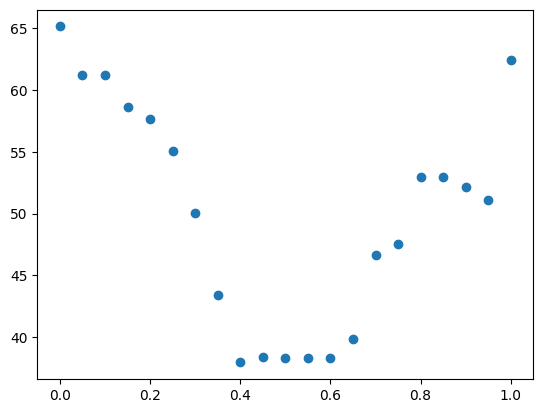

In [ ]:
plt.scatter(alpha, recall)

## Post-processing

In [ ]:
def reconstruct_segments(probs, timestamps, transcripts):
    return [
        {
            'start': round(start.item(), 2),
            'end': round(end.item(), 2),
            'speaker': speaker[0].item(),
            'text': text[0],
            'model_probability': round(prob.item(), 4)
        }
        for prob, (start, end), (speaker, text) in zip(probs, timestamps, transcripts) if prob > 0.35
    ]

## Evaluation

221
180
193


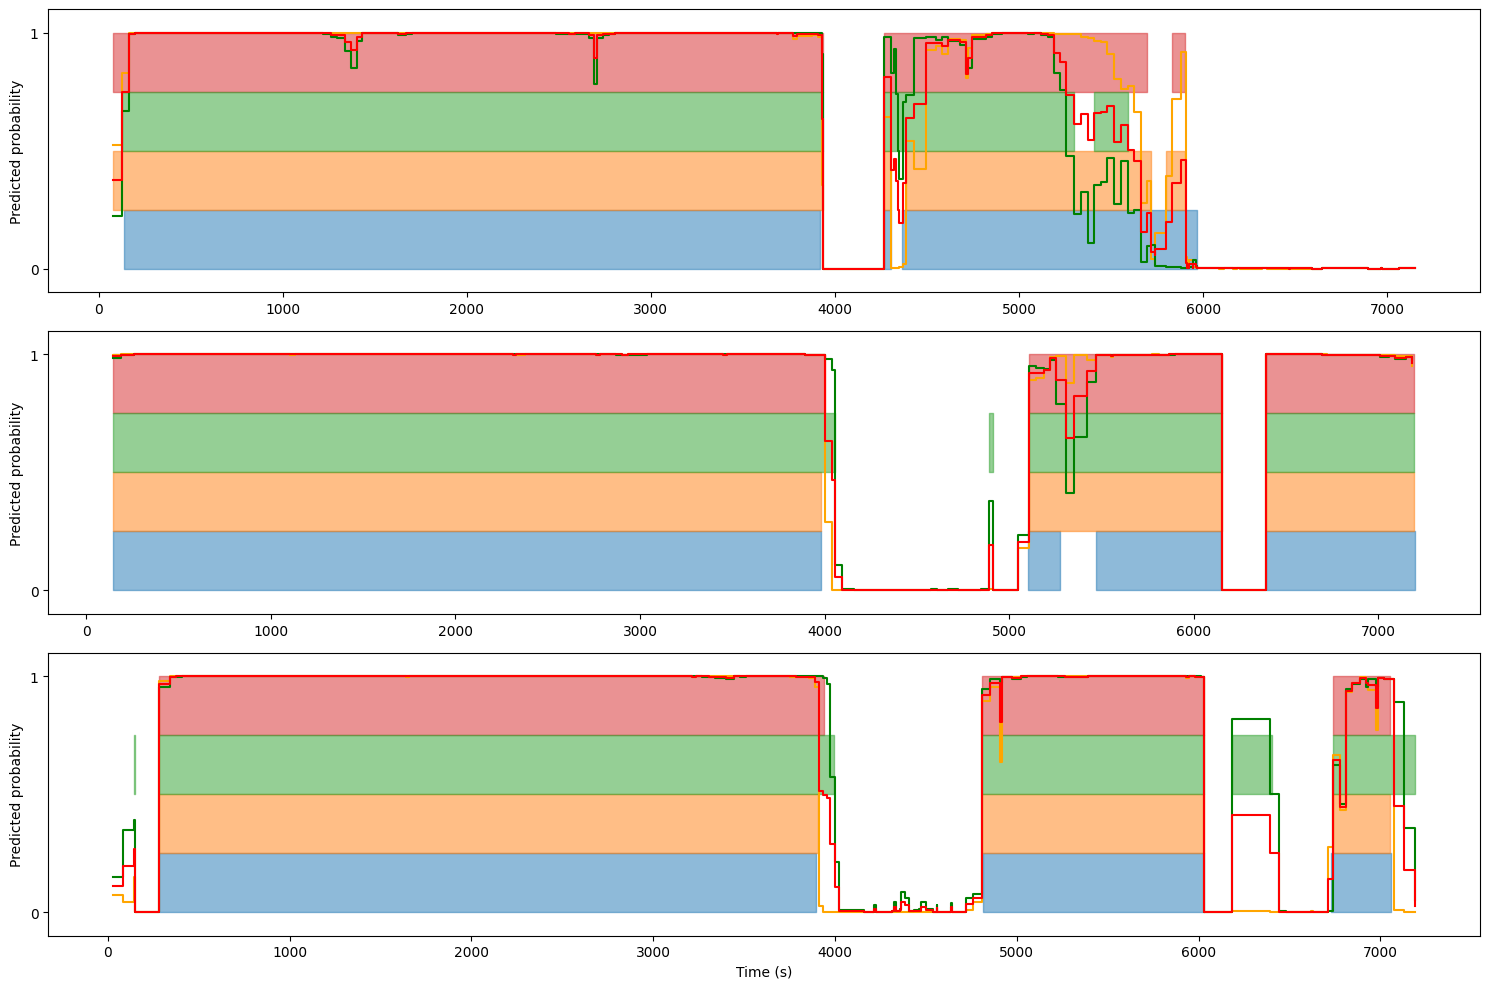

In [ ]:
course = '60037'
_, dataset_audio = LectureDataset.from_data_dir(val=course, embedding_names=['audio_embedding', 'diarization_embedding'])#, require_update=['labels', 'ground_truth'])
_, dataset_text = LectureDataset.from_data_dir(val=course, embedding_names=['text_embedding', 'diarization_embedding'])
loader_audio = DataLoader(dataset_audio, batch_size=BATCH_SIZE, shuffle=False)
loader_text = DataLoader(dataset_text, batch_size=BATCH_SIZE, shuffle=False)
model_audio, model_text = models_audio[course], models_text[course]

fig, axes = plt.subplots(len(loader_audio), 1, figsize=(15, 10))
loss_fn = nn.BCEWithLogitsLoss()
results = []
#reconstructed_transcripts = {}

model_audio.eval()
model_text.eval()
with torch.no_grad():
    for sample_audio, sample_text in zip(loader_audio, loader_text):
        features, timestamps, ground_truth, audio_path, transcripts = sample_audio['features'], \
            sample_audio['timestamps'], sample_audio['ground_truth'], sample_audio['audio_path'], sample_audio['transcripts']
        logits = model_audio(features)
        probs = torch.sigmoid(logits)

        features = sample_text['features']
        logits = model_text(features)
        probs2 = torch.sigmoid(logits)

        probs_ = 0.65 * probs + 0.35 * probs2
        preds = probs_ > THRESHOLD - 0.15
        preds = extend_relevant_segments(preds.squeeze(0), timestamps.squeeze(0), transcripts).unsqueeze(0)
        timestamps_ = timestamps
        timestamps = merge_gap(timestamps[preds], gap=60)
        iou = compute_iou(ground_truth[0], timestamps)
        iou = iou[0] / (iou[1] + 1e-8)
        results.append((audio_path[0], probs, probs2, preds, timestamps_, timestamps, ground_truth[0], transcripts, iou))

        reconstructed_transcripts[audio_path[0]] = reconstruct_segments(probs_.squeeze(0), timestamps_.squeeze(0), transcripts)

errors = np.array([loss for *_, loss in results])
least_accurate = np.argsort(errors)[:5]
cmap = plt.get_cmap('tab10')
for i, index in enumerate(least_accurate):
    audio_path, probs, probs2, preds, timestamps_, timestamps, ground_truth, transcripts, iou = results[index]

    for segment in ground_truth.cpu():
        start, end = segment[0], segment[1]
        axes[i].broken_barh([(start, end - start)], (0, 0.25), color=cmap(0), alpha=0.5)
    for segment in timestamps.cpu():
        start, end = segment[0], segment[1]
        axes[i].broken_barh([(start, end - start)], (0.75, 0.25), color=cmap(3), alpha=0.5)

    preds_ = probs > THRESHOLD - 0.15
    preds = extend_relevant_segments(preds_.squeeze(0), timestamps_.squeeze(0), transcripts).unsqueeze(0)
    timestamps = merge_gap(timestamps_[preds_], gap=60)
    for segment in timestamps.cpu():
        start, end = segment[0], segment[1]
        axes[i].broken_barh([(start, end - start)], (0.25, 0.25), color=cmap(1), alpha=0.5)

    preds_ = probs2 > THRESHOLD - 0.15
    preds = extend_relevant_segments(preds_.squeeze(0), timestamps_.squeeze(0), transcripts).unsqueeze(0)
    timestamps = merge_gap(timestamps_[preds_], gap=60)
    for segment in timestamps.cpu():
        start, end = segment[0], segment[1]
        axes[i].broken_barh([(start, end - start)], (0.5, 0.25), color=cmap(2), alpha=0.5)

    timestamps = timestamps_[0].cpu().numpy()
    timestamps_ = list(float(t) for t in timestamps[:, 0])
    probs, probs2 = probs.cpu().numpy().flatten(), probs2.cpu().numpy().flatten()
    probs_ = (probs + probs2) / 2
    probs, probs2, probs_ = list(float(p) for p in probs), list(float(p) for p in probs2), list(float(p) for p in probs_)
    for j in range(len(timestamps_) - 2, -1, -1):
        t1, t2 = timestamps[j, 1], timestamps[j + 1, 0]
        if t2 - t1 > 60:
            timestamps_.insert(j + 1, t1 + 1)
            probs.insert(j + 1, 0)
            probs2.insert(j + 1, 0)
            probs_.insert(j + 1, 0)
    print(len(timestamps_))
    axes[i].step(timestamps_, probs, where='post', color='orange')
    axes[i].step(timestamps_, probs2, where='post', color='green')
    axes[i].step(timestamps_, probs_, where='post', color='red')
    axes[i].set_ylabel('Predicted probability')
    axes[i].set_ylim(-0.1, 1.1)
    axes[i].set_yticks([0, 1])
    #axes[i].set_title(audio_path + ' ' + str(iou))

plt.xlabel('Time (s)')
plt.tight_layout()
plt.savefig(path / 'prediction.png', dpi=300)
plt.show()

In [ ]:
print(json.dumps(reconstructed_transcripts['60034/2026-02-20.wav'], indent=2))

[
  {
    "start": 211.57,
    "end": 241.75,
    "speaker": 0,
    "text": "Well, Sorry for the confusion in terms of the arrangement of the lectures, right? ",
    "model_probability": 0.6895
  },
  {
    "start": 241.77,
    "end": 272.9,
    "speaker": 0,
    "text": "So I've put the latest schedule on and really starting for next week, our number 10 AI fellow, Harry, will come. So this week should be the week that you should have watched some videos about RNNs and tension basics. So there are some questions on asking about essentially the contents, right? So I want to clarify this in terms of these interesting red star titles. ",
    "model_probability": 0.9931
  },
  {
    "start": 273.56,
    "end": 303.83,
    "speaker": 0,
    "text": "Okay? So, in the notes, right, if you see basically the content with these rest dot titles, then it basically just means that it is non-executable. So, for example, if you look at, for example, like the RNN notes, right, so let's say long, short

## LLM

In [ ]:
import json
from google import genai

CHUNK_PROMPT = """
You are analyzing a contiguous chunk of a lecture transcript.

Input:

{
  "segments": [
    {
      "start": <number>,
      "end": <number>,
      "speaker_id": "...",
      "text": "..."
    }
  ]
}

Return JSON only:

{
  "summary": "...",
  "topics": [
    {
      "name": "...",
      "summary": "..."
    }
  ],
  "bookmark_candidates": [
    {
      "timestamp": <number>,
      "title": "...",
      "importance": <float>
    }
  ]
}

Requirements:

- Summarize the chunk.
- Extract major topics.
- Identify major topic transitions.
- Only create bookmark candidates for substantial topic changes.
- Importance must be between 0 and 1.
- Copy timestamps exactly from the transcript. Never invent timestamps.
- Return valid JSON only.

Importance:

0.0–0.3:
Minor supporting material.

0.3–0.6:
Useful concept or example.

0.6–0.8:
Important topic.

0.8–1.0:
Major topic or critical takeaway.
"""

MERGE_PROMPT = """
You are merging summaries from consecutive portions of the same lecture.

Input contains a sequence of objects with:

- summary
- topics
- bookmark_candidates

Return JSON only:

{
  "summary": "...",
  "topics": [
    {
      "name": "...",
      "summary": "..."
    }
  ],
  "bookmark_candidates": [
    {
      "timestamp": <number>,
      "title": "...",
      "importance": <float>
    }
  ]
}

Requirements:

Summary:

- Produce a coherent merged summary.
- Preserve all major concepts.
- Remove redundant information.
- Compress repeated explanations into a single description.
- Maintain overall chronological flow.

Topics:

- Merge semantically equivalent topics.
- Use a single canonical topic name.
- Combine similar topic summaries.
- Remove duplicates.

When merging:

- Keep the earliest timestamp.
- Keep the most informative title.
- Keep the highest importance score.

Output valid JSON only.
"""

BOOKMARK_PROMPT = """
You are refining bookmarks for a lecture video.

Input:

{
  "summary": "...",
  "topics": [...],
  "bookmark_candidates": [...]
}

Generate a final bookmark list.

Return JSON only:

[
  {
    "timestamp": <number>,
    "title": "..."
  }
]

Requirements:

Goal:

Produce a concise set of bookmarks that maximizes navigation usefulness.

Bookmark selection:

- Prefer candidates with higher importance.
- Remove redundant candidates.
- Remove low-information candidates.
- Remove candidates that represent minor clarifications.

Merge bookmarks when:

- They describe the same topic.
- They occur close together in time.
- One is clearly a continuation of the other.

Titles:

- Use concise chapter-style titles.
- Prefer noun phrases.
- Avoid vague wording.

Ordering:

- Preserve chronological order.
- Ensure timestamps are unique.

Output valid JSON only.
"""
def gemini_json(client, model, prompt, content):
    response = client.models.generate_content(
        model=model,
        contents=content,
        config={
            "system_instruction": prompt,
            "temperature": 0.0,
            'response_mime_type': 'application/json'
        }
    )

    text = response.text.strip()
    if text.startswith("```"):
        text = text.split("\n", 1)[1]
        text = text.rsplit("```", 1)[0]

    return json.loads(text)

def summarize_chunk(client, model, chunk):
    transcript = "\n".join(f"[{seg['start']:.1f}-{seg['end']:.1f}] {seg['text']}" for seg in chunk)

    return gemini_json(
        client,
        model,
        CHUNK_PROMPT,
        transcript
    )

def merge_nodes(client, model, nodes):
    return gemini_json(
        client,
        model,
        MERGE_PROMPT,
        json.dumps(nodes, ensure_ascii=False)
    )

def filter_candidates(candidates, min_importance=0.5, min_gap=300):
    candidates = [c for c in candidates if c["importance"] >= min_importance]
    candidates.sort(key=lambda x: x["timestamp"])

    filtered = []
    for c in candidates:
        if not filtered:
            filtered.append(c)
            continue

        if c["timestamp"] - filtered[-1]["timestamp"] < min_gap:
            if c["importance"] > filtered[-1]["importance"]:
                filtered[-1] = c
        else:
            filtered.append(c)

    return filtered

def refine_bookmarks(client, model, summary, candidates):
    payload = {"lecture_summary": summary, "bookmark_candidates": candidates}
    return gemini_json(
        client,
        model,
        BOOKMARK_PROMPT,
        json.dumps(payload, ensure_ascii=False)
    )

def hierarchical_lecture_summary(segments, api_key, model="gemini-2.5-pro", chunk_size=40, merge_factor=5):
    client = genai.Client(api_key=api_key)
    nodes = []

    # Level 0
    for i in range(0, len(segments), chunk_size):
        chunk = segments[i:i + chunk_size]
        node = summarize_chunk(client, model, chunk)
        nodes.append(node)

    # Hierarchical merging
    while len(nodes) > 1:
        merged_nodes = []
        for i in range(0, len(nodes), merge_factor):
            group = nodes[i:i + merge_factor]
            merged_nodes.append(merge_nodes(client, model, group))
        nodes = merged_nodes

    root = nodes[0]
    candidates = filter_candidates(root["bookmark_candidates"])
    bookmarks = refine_bookmarks(client, model, root["summary"], candidates)

    return {
        "summary": root["summary"],
        "topics": root["topics"],
        "bookmarks": bookmarks
    }

start = time.perf_counter()
result = hierarchical_lecture_summary(
    segments=reconstructed_transcripts['60034/2026-02-20.wav'],
    api_key=api,
    chunk_size=40,
    merge_factor=5
)
print(time.perf_counter() - start)

print(result["summary"])

for bookmark in result["bookmarks"]:
    print(
        bookmark["timestamp"],
        bookmark["title"]
    )

# 6, 6, 0.7, 10, 47, 0, 0, 3
# 1, 10, 8, 16, 7,
# 0, 0, 19, 6, 10

80.85877856300067
The lecture begins with administrative details, clarifying that content marked with a red star is non-examinable. The core technical discussion starts with a detailed derivation of the diffusion model objective from a Variational Autoencoder (VAE) perspective, showing how factorizing the KL divergence leads to a denoising objective. The lecturer compares Latent Diffusion Models (LDMs) to VAEs, explaining that LDM's superior performance stems from learning the 'aggregated posterior' of the latent space, thus avoiding the prior mismatch issue common in VAEs. This leads to an analysis of the reconstruction-generation trade-off in VAEs. The topic then transitions to backpropagation in Recurrent Neural Networks (RNNs), highlighting how recurrent dependencies create complex gradients that can vanish or explode. Following this, the lecture examines the computational complexity of modern architectures, specifically the quadratic complexity (O(n^2*d)) of the attention mechanis

This lecture introduces the law of contract, explaining its sources in the English common law system, which relies on historical precedent (stare decisis) and a hierarchy of courts. A contract is defined as a legally enforceable private agreement, with the first essential element being "agreement," achieved through "offer and acceptance." The lecture distinguishes between an "offer" and an "invitation to treat," using cases like Pharmaceutical Society v Boots to show that goods in shops are invitations. It then explores contract formation in remote and automated transactions, discussing communication failures and the concept of a "unilateral contract" through the landmark case of Carlill v Carbolic Smoke Ball Company. Another key element, "consideration," is explained as the requirement for both parties to provide something of value, even if nominal, as illustrated by cases like Chappell v. Nestlé. The lecture concludes by covering remedies for breach of contract, starting with damages, specific performance (for unique items), and injunctions, before delving into liquidated damages clauses. It clarifies that liquidated damages are valid only if they are a genuine pre-estimate of loss and not an unenforceable penalty clause, as established in the Dunlop Pneumatic Tire case.


The lecture begins with administrative details about the course schedule and non-examinable content before diving into the design of diffusion models from a Variational Autoencoder (VAE) perspective. This involves factorizing the Q distribution to match the P distribution, simplifying the objective to a denoising task. The discussion contrasts Latent Diffusion Models (LDMs) with VAEs, explaining how LDMs solve the VAE's aggregated posterior problem and highlighting the trade-off between reconstruction and generation quality. The lecture then transitions to Recurrent Neural Networks (RNNs), introducing backpropagation through time and its associated gradient complexities. Following this, the focus shifts to Transformers, analyzing the quadratic computational complexity of the attention mechanism and the necessity of positional encodings to address its permutation-equivariant nature. A surprising connection is then drawn between attention and RNNs, demonstrating that linear attention (without softmax) is mathematically equivalent to an RNN with a matrix-valued state. This equivalence is highlighted as a driver for recent innovations in efficient architectures like "gated data net." The lecture concludes by emphasizing that a deep understanding of fundamentals like linear algebra is crucial for these architectural innovations and announces topics for the upcoming weeks.
453.2 Diffusion Models from a VAE Perspective
1159.7 Latent Diffusion Models vs. VAEs
1922.2 The Quadratic Complexity of Attention
2354.0 Positional Encodings in Transformers
2895.7 The Connection Between Linear Attention and RNNs
3670.0 Conclusion: Importance of Fundamentals

The lecture begins with a comprehensive overview of the second coursework, which focuses on NeurASP. The coursework is designed to emulate a researcher's workflow, guiding students through familiarizing with, modifying, comparing, and extending a neurosymbolic system. The lecturer covers logistical details like submission, grading, and deadlines before transitioning to the main topic: learning Answer Set Programming (ASP) programs. The concept of "cautious induction" is introduced, a strict framework where any learned hypothesis must entail positive examples and not negative ones across all its answer sets. A detailed example demonstrates how to verify a cautious inductive solution by constructing groundings, reducts, and answer sets. However, the lecturer explains that cautious induction is too restrictive for learning certain rules (like choice rules), which motivates the introduction of a more flexible approach: "brave induction". Brave induction only requires that at least one answer set covers the examples. The lecture then introduces the ASPAL system, which implements brave induction by encoding the entire learning problem into ASP. This involves creating a search space of "skeletal rules" from a language bias, making them safe with unique 'flag' predicates, and using a choice rule to allow an ASP solver to select the best subset of rules. The learning goal is enforced with constraints, and an optimization statement is used to find the most general (shortest) solution. The lecture concludes with a discussion of course logistics, future plans including guest lectures, and an extended Q&A session. During the Q&A, the efficiency of learning algorithms is discussed, highlighting that learning constraints during the process can effectively prune the search space, which is far more efficient than brute-force generation and testing of rule combinations.
258.2 Coursework 2 Overview
1062.2 Learning ASP: Cautious Induction
1526.3 Example: Verifying a Cautious Solution
2438.0 Limitations and Introduction to Brave Induction
3085.9 The ASPAL System for Brave Induction
4503.6 Encoding and Optimizing in ASPAL
5760.4 Course Logistics and Future Plans
6092.6 Q&A: Learning Efficiency

The lecture begins with an introduction to the course on type systems, covering its theoretical nature, structure, and logistics. The focus then shifts to the foundational topic of lambda calculus, introduced as a model of computation based on defining and simplifying anonymous functions. The lecture details its formal syntax (variables, abstraction, application), syntactic sugar, and the concept of reduction as a computational step. A key problem, "variable capture," is introduced, leading to the formal definition of free and bound variables. To solve this, the lecture defines alpha equivalence, which allows for the safe renaming of bound variables. A formal, complex definition of substitution is presented that avoids variable capture, followed by Barendregt's Convention, a simplifying assumption that allows for a much simpler substitution definition. The core computational rule, one-step beta reduction, is then introduced as substituting an argument into a function's body. This reduction can occur anywhere in a term (congruence), and a reducible expression is called a 'redex'. The lecture explains that due to the Church-Rosser theorem (confluence), the order of reducing multiple redexes does not affect the final outcome. This leads to the formalization of multi-step reductions and beta equivalence. Finally, the concept of "normal form" is defined for terms that cannot be reduced further, distinguishing between normalizable (terminating) and non-terminating terms. The omega combinator is shown as a classic non-terminating term, and the lecture concludes by demonstrating how to create useful loops with the Y combinator.


In [ ]:

start = time.perf_counter()
result3 = hierarchical_lecture_summary(
    segments=reconstructed_transcripts['60023/2025-10-07.wav'],
    api_key=api,
    chunk_size=40,
    merge_factor=5
)
print(time.perf_counter() - start)

print(result3["summary"])

for bookmark in result3["bookmarks"]:
    print(
        bookmark["timestamp"],
        bookmark["title"]
    )
# 6, 13, 8, 0, 19, 15, 18

86.93818299600025
The lecture begins with an introduction to a course on type systems for programming languages, covering logistical details before diving into the main technical content: the lambda calculus. It is presented as a model of computation based on defining and simplifying anonymous functions. The lecture first establishes the formal syntax (variables, abstraction, application) and then introduces computation as 'reduction,' which involves substitution. This immediately raises the critical problem of 'variable capture.' To address this, the concepts of free and bound variables are formally defined, leading to the principle of alpha equivalence (α-equivalence), which allows for the safe renaming of bound variables. After presenting a complex, case-by-case definition of substitution designed to prevent variable capture, the lecture introduces Barendregt's Convention as a simplification, which assumes free and bound variables are always distinct. With these foundations, the cor

The lecture begins by revisiting the Y combinator and its role in finding fixed points in lambda calculus, where a fixed point `n` of a function `m` satisfies `m(n) = n`. This property is key to implementing recursion. The lecture introduces syntactic sugar (`let rec`) and extends lambda calculus with numbers and case analysis to demonstrate recursive function implementation. The discussion then shifts to evaluation strategies for beta reduction, using the non-terminating term Omega to illustrate how the choice of which reducible expression (redex) to evaluate first affects termination. The lecture contrasts call-by-value ("strict") with call-by-name ("lazy") evaluation, discussing their trade-offs. Following this, the course transitions from untyped to typed lambda calculus, introducing types as a way to prevent nonsensical programs. The lecture covers the intuition behind function (arrow) types and begins to formalize the system by defining Curry types, typing contexts (gamma), and the syntax for typing judgments. Finally, the formal type system is detailed through inference rules. The three core rules—Axiom (for variables), Arrow Introduction (for lambda abstractions), and Arrow Elimination (for function applications)—are explained. The lecturer demonstrates how to use these rules to build derivation trees and assign types to lambda terms through several examples.


In [ ]:
start = time.perf_counter()
result4 = hierarchical_lecture_summary(
    segments=reconstructed_transcripts['60023/2025-10-10.wav'],
    api_key=api,
    chunk_size=40,
    merge_factor=5
)
print(time.perf_counter() - start)

print(result4["summary"])

for bookmark in result4["bookmarks"]:
    print(
        bookmark["timestamp"],
        bookmark["title"]
    )
# 0, 0, 0, 0, 3, 0

KeyError: '60023/2025-10-10.wav'

In [ ]:

start = time.perf_counter()
result2 = hierarchical_lecture_summary(
    segments=reconstructed_transcripts['60023/2025-11-11.wav'],
    api_key=api,
    chunk_size=40,
    merge_factor=5
)
print(time.perf_counter() - start)

print(result2["summary"])

for bookmark in result2["bookmarks"]:
    print(
        bookmark["timestamp"],
        bookmark["title"]
    )

KeyError: '60023/2025-11-11.wav'

0.536599721827013


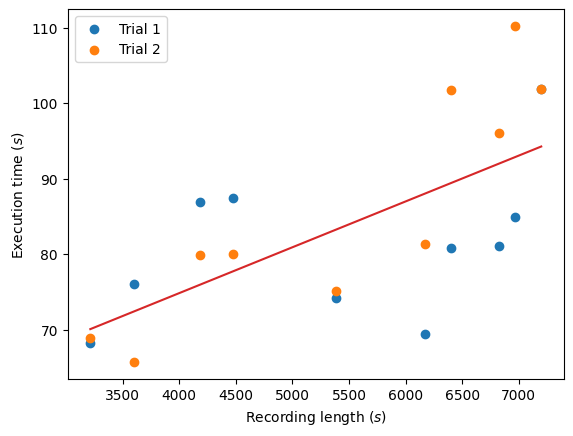

In [ ]:
profiles_llm = np.vstack((profiles_[:, 0], np.array([68.25, 76.03, 86.93, 87.39, 74.18, 69.36, 80.85, 81.07, 84.95, 101.80, ]), np.array([68.81545831599942,
65.70936473299662,
79.8110607799972,
79.98179376100234,
75.07886019000216,
81.2729378389995,
101.69143405900104,
96.02737162099947,
110.21253273600087,
101.8722308940014])))
plt.scatter(profiles_llm[0], profiles_llm[1], label='Trial 1')
plt.scatter(profiles_llm[0], profiles_llm[2], label='Trial 2')
m, b = np.polyfit(np.hstack((profiles_llm[0], profiles_llm[0])), np.hstack((profiles_llm[1], profiles_llm[2])), 1)
y = m * profiles_llm[0] + b
plt.plot(profiles_llm[0], y, color=cmap(3))
avg = np.mean(profiles_llm[1] + profiles_llm[2]) / 2
print((np.sum((profiles_llm[1] - y) ** 2) + np.sum((profiles_llm[2] - y) ** 2)) / (np.sum((profiles_llm[1] - avg) ** 2) + np.sum((profiles_llm[2] - avg) ** 2)))

plt.xlabel('Recording length ($s$)')
plt.ylabel('Execution time ($s$)')
plt.legend()
plt.savefig(path / 'execution.png', dpi=300)

In [ ]:
for length, first, second in zip(profiles_llm[:10], profiles_llm[10:20], profiles_llm[20:30]):
    print(f'{length:.0f} & {first:.2f} & {second:.2f} \\\\')

3215 & 68.25 & 68.82 \\
3598 & 76.03 & 65.71 \\
4182 & 86.93 & 79.81 \\
4472 & 87.39 & 79.98 \\
5382 & 74.18 & 75.08 \\
6167 & 69.36 & 81.27 \\
6398 & 80.85 & 101.69 \\
6821 & 81.07 & 96.03 \\
6964 & 84.95 & 110.21 \\
7198 & 101.80 & 101.87 \\


## Utils

In [ ]:
update_lecture_entry('60017/2026-02-16.wav',[
    {'start': (251,), 'end': (2293,), 'label': 1},
    {'start': (2362,), 'end': (2370,), 'label': 1},
    {'start': (2539,), 'end': (2613,), 'label': 1},
    {'start': (2836,), 'end': (2944,), 'label': 1},
    {'start': (3078,), 'end': (3414,), 'label': 1},
    {'start': (3986,), 'end': (1, 7, 20), 'label': 1},
    {'start': (1, 8, 26), 'end': (5909,), 'label': 1},
    {'start': (5983), 'end': 7172, 'label': 1}
], path=path/'data')

[{'start': 251, 'end': 2293, 'label': 1}, {'start': 2362, 'end': 2370, 'label': 1}, {'start': 2539, 'end': 2566, 'label': 1}, {'start': 2580, 'end': 2613, 'label': 1}, {'start': 2836, 'end': 2880, 'label': 1}, {'start': 2911, 'end': 2944, 'label': 1}, {'start': 3078, 'end': 3170, 'label': 1}, {'start': 3190, 'end': 3414, 'label': 1}, {'start': 3986, 'end': 4206, 'label': 1}, {'start': 4262, 'end': 5150, 'label': 1}, {'start': 5197, 'end': 5909, 'label': 1}, {'start': 5983, 'end': 7172, 'label': 1}]
Found existing entry in /content/drive/MyDrive/Individual_Project/data/labels.json for 60017/2026-02-16.wav.
Override the entry? (Y/N) Y
File updated.


In [ ]:
update_lecture_entry('60017/2026-01-19.wav', [
    {'start': (222,), 'end': (3608,), 'label': 1},
    {'start': (4206,), 'end': (1, 37, 30), 'label': 1},
    {'start': (1, 39, 12), 'end': (1, 39, 26), 'label': 1},
    {'start': (1, 43, 44), 'end': (1, 44, 34), 'label': 1},
    {'start': (1, 49, 35), 'end': (6797,), 'label': 1},
    #{'start': (3814,), 'end': (6613,), 'label': 1},
    #{'start': (1, 5, 38), 'end': (1, 5, 53), 'label': 1},
    #{'start': (1, 10, 16), 'end': (6833,), 'label': 1}
], path=path/'data')

[{'start': 222, 'end': 3608, 'label': 1}, {'start': 4206, 'end': 5850, 'label': 1}, {'start': 5952, 'end': 5966, 'label': 1}, {'start': 6224, 'end': 6274, 'label': 1}, {'start': 6575, 'end': 6797, 'label': 1}]
Found existing entry in /content/drive/MyDrive/Individual_Project/data/labels.json for 60017/2026-01-19.wav.


KeyboardInterrupt: Interrupted by user

In [ ]:
def load_labels(path):
    if Path(path).exists():
        with open(path, 'r') as f:
            data = json.load(f)
    else:
        data = []
    return data

def time_to_secs(time):
    if isinstance(time, tuple):
        return sum(60 ** i * t for i, t in enumerate(time[::-1]))
    return time

def update_lecture_entry(audio_path, segments, meta=None, path='./data'):
    path = Path(path) / 'labels.json'
    data = load_labels(path)
    for segment in segments:
        segment['start'] = time_to_secs(segment['start'])
        segment['end'] = time_to_secs(segment['end'])

    for entry in data:
        if entry['audio_path'] == audio_path:
            print(entry['segments'])
            print(f'Found existing entry in {path} for {audio_path}.')
            user_input = ''
            while user_input not in ('y', 'n'):
                user_input = input('Override the entry? (Y/N) ').lower()
            if user_input == 'n':
                return
            entry['segments'] = segments
            if meta:
                entry['meta'].update(meta)
            break
    else:
        raise
        print(f'No existing entry found. Creating new entry...')
        entry = {
            'audio_path': audio_path,
            'labels': [],
            'segments': segments,
            'meta': meta or {}
        }
        data.append(entry)

    with open(path, 'w') as f:
        json.dump(data, f, indent=2)
    print('File updated.')